# The SKHY ADR premium as a reflected process

**Notebook 01 — premium anatomy.** Stage S2 (M1 measurement layer), `charon`.

---

## 1. Motivation and framing

SK Hynix listed ADRs on Nasdaq on 2026-07-10 under **SKHY**, at a ratio of **10 ADRs to
one Korean common share**. The ADR has traded at a persistent premium to the underlying
ever since — peaking around 51%, and sitting near 22% at the end of July.

A premium of that size ordinarily invites an arbitrage that closes it. Here it cannot,
because the conversion channel is **one-way**:

- **ADR → local** is uncapped and fast. If the premium goes negative, buy the ADR,
  cancel it, sell the local share. This makes the premium a *reflected* process near
  conversion cost **from below**.
- **local → ADR** is bounded by a **2.5% quota that was fully exhausted at the
  offering**. With headroom at zero, nothing structurally caps the premium **from
  above**.

Three consequences organise everything downstream:

1. **π is not a mean-reverting spread.** Modelling it as an Ornstein–Uhlenbeck process is
   misspecified. The correct null is a process with one-sided reflection and a
   state-dependent upper drift.
2. **Every short-premium expression is short a barrier that does not exist** — negatively
   skewed by construction, not by bad luck.
3. **The barrier's state is observable**, via quota headroom, which turns regime
   modelling into a data problem rather than a latent-variable guess.

This notebook does none of that modelling. It does the thing that has to be right first:
**construct π correctly, and quantify how much of it is measurement rather than
economics.**

### Status of claims in this notebook — read this before quoting anything

`preregistration/calls.yaml` records this project's hypotheses. Its freeze state governs
what may be called a pre-registered forward test.

The cell below reads that state and prints the governing caption. **Nothing in this
notebook is described as a blind pre-event forward test unless the ledger says it is**,
on the record, by commit.

In [1]:
import subprocess, yaml, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
calls = yaml.safe_load((ROOT / "preregistration" / "calls.yaml").read_text())
n_commits = int(subprocess.run(["git","rev-list","--all","--count"], cwd=ROOT,
                capture_output=True, text=True).stdout.strip() or 0)
frozen = calls.get("frozen_at")
classes = {k: v.get("freeze_class") for k, v in calls.items()
           if isinstance(v, dict) and "statement" in v}

if frozen and n_commits:
    print(f"Ledger FROZEN at {frozen} ({n_commits} commits).")
    for h, c in classes.items():
        print(f"  {h}: freeze_class={c}")
    print("\nOnly calls marked freeze_class C or P below are pre-registered.")
else:
    print(f"Ledger NOT FROZEN (frozen_at={frozen!r}, commits={n_commits}).")
    print()
    print("CAPTION GOVERNING THIS ENTIRE NOTEBOOK:")
    print("  Every hypothesis is EXPLORATORY. No claim here is pre-registered, and")
    print("  Class P is empty -- no call predates the 2026-07-29 earnings release on")
    print("  the record. This is stated plainly rather than elided; an honestly")
    print("  labelled exploratory analysis is a legitimate artifact, and a")
    print("  mislabelled 'forward test' is not.")

Ledger FROZEN at 2026-07-29T05:20:00+00:00 (24 commits).
  h1_term_structure: freeze_class=X
  h2_index_access: freeze_class=X
  h3_letf_loop: freeze_class=X
  h4_vol_decomposition: freeze_class=X
  h5_quota_ledger: freeze_class=C

Only calls marked freeze_class C or P below are pre-registered.


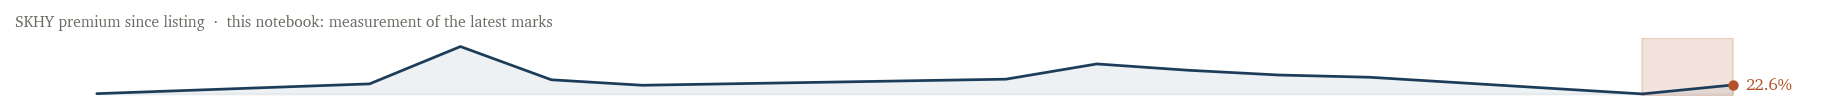

In [2]:
%matplotlib inline
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from pipeline.viz import theme
from pipeline.measurement.premium import build_all_variants
theme.apply()
_pi = build_all_variants("skhy")[0].series
theme.sparkline_header(_pi, highlight=("2026-07-27", "2026-07-28"),
                       label="SKHY premium since listing  ·  this notebook: measurement of the latest marks");

---

## 2. Data provenance

Generated from the metadata sidecars written at ingestion — not hand-maintained, so it
cannot drift from what was actually pulled.

Two things worth noticing in the table:

- **SKHY comes from Nasdaq and 2330 from TWSE** — each instrument's *own listing
  exchange*, not an aggregator. This repo began on a single aggregator; a provider
  outage forced a rebuild onto a multi-provider adapter, and the result is better
  provenance than the original design had.
- **USD/KRW is held twice**, from two differently-timed fixes. That redundancy is not
  belt-and-braces; it is the instrument used in §5 to *measure* how much of a premium
  change is an artifact of the FX clock.

In [3]:
import json, pathlib, pandas as pd
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
rows = []
for meta in sorted((ROOT / "data" / "raw").rglob("*.csv.meta.json")):
    m = json.loads(meta.read_text())
    rows.append({
        "series": m["series_id"], "provider": m.get("provider"),
        "rows": m.get("rows"), "from": m.get("first_obs_date"), "to": m.get("last_obs_date"),
        "tz": m.get("native_timezone"), "units": m.get("units"),
        "timing_confirmed": m.get("availability_confirmed"),
    })
prov = pd.DataFrame(rows)
prov

,series,provider,rows,from,to,tz,units,timing_confirmed
0,skhy_adr_daily,nasdaq,13,2026-07-10,2026-07-28,America/New_York,USD per ADR,False
1,skhynix_local_daily,eodhd,243,2025-07-29,2026-07-28,Asia/Seoul,KRW per common share,False
2,usdkrw_spot_daily,frankfurter,2962,2014-12-31,2026-07-28,UTC,KRW per 1 USD,False
3,usdkrw_spot_fred_daily,fred,2889,2015-01-02,2026-07-24,America/New_York,KRW per 1 USD,False
4,skhynix_local_daily,eodhd,2839,2015-01-02,2026-07-28,Asia/Seoul,KRW per common share,False
5,skhynix_dr_headroom_capped,ksd_seibro,1,2026-07-15,2026-07-15,Asia/Seoul,shares (remaining ordinary shares convertible ...,None
6,skhynix_dr_headroom_legacy,ksd_seibro,1260,2010-03-31,2026-07-28,Asia/Seoul,shares (remaining ordinary shares convertible ...,None
7,baba_adr_daily,nasdaq,2513,2016-07-28,2026-07-28,America/New_York,USD per ADS,False
8,baba_local_daily,eodhd,1638,2019-11-26,2026-07-28,Asia/Hong_Kong,HKD per common share,False
9,ibn_adr_daily,nasdaq,2513,2016-07-28,2026-07-28,America/New_York,USD per ADR,False


In [4]:
# Availability lags, verbatim from the sidecars. The information-timing firewall
# (README section 4): nothing enters a forecast made at time t unless it was publicly
# knowable before t in the relevant timezone.
for meta in sorted((ROOT / "data" / "raw").rglob("*.csv.meta.json")):
    m = json.loads(meta.read_text())
    print(f"{m['series_id']:26s} {m.get('availability_lag')}")

skhy_adr_daily             close 16:00:00 America/New_York + 15min
skhynix_local_daily        close 15:30:00 Asia/Seoul + 15min
usdkrw_spot_daily          close 21:00:00 UTC + 0min
usdkrw_spot_fred_daily     close 12:00:00 America/New_York + 360min
skhynix_local_daily        close 15:30:00 Asia/Seoul + 15min
skhynix_dr_headroom_capped TODO(ash): KSD's publication time for the daily capacity figure is unverified. Rows appear to be published on change rather than daily.
skhynix_dr_headroom_legacy TODO(ash): KSD's publication time for the daily capacity figure is unverified. Rows appear to be published on change rather than daily.
baba_adr_daily             close 16:00:00 America/New_York + 15min
baba_local_daily           close 16:00:00 Asia/Hong_Kong + 15min
ibn_adr_daily              close 16:00:00 America/New_York + 15min
infy_adr_daily             close 16:00:00 America/New_York + 15min
tsm_adr_daily              close 16:00:00 America/New_York + 15min
tsmc_local_daily           clos

---

## 3. Formulas

### 3.1 The premium

README §3 defines

$$\pi_t \;=\; \frac{P^{ADR}_t}{P^{local}_t \cdot FX_t / 10} - 1$$

where $/10$ is the SKHY deal ratio and $FX_t$ is written **USD per local unit**.

Public FX series are quoted the other way round — `KRW=X` and `DEXKOUS` are **local units
per USD**. Substituting $FX = 1/FX^{local/USD}$ and generalising the ratio to $n_t$ local
shares per ADR gives the form actually implemented:

$$\boxed{\;\pi_t \;=\; \frac{P^{ADR}_t \cdot FX^{local/USD}_t}{n_t \cdot P^{local}_t} - 1\;}$$

**The FX quote direction is the single most common way this calculation is silently
wrong.** The units check: $n_t P^{local}$ is the local-currency cost of the shares
underlying one ADR; multiplying the numerator by $FX^{local/USD}$ puts the ADR's USD price
into that same currency. Both sides local currency, ratio dimensionless.

Inverting FX does **not** produce a subtly wrong answer — it produces roughly $-99.99\%$.
That is asserted in the test suite, precisely so the failure stays loud.

$n_t$ is **subscripted by date**: ADR ratios change, and an unhandled ratio change is
indistinguishable from a premium jump. $n = 0.1$ for SKHY (10 ADRs = 1 share), $n = 5$
for TSM.

In [5]:
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import inspect
from pipeline.measurement.premium import compute_premium
print(inspect.getsource(compute_premium))

def compute_premium(
    adr_close: pd.Series,
    local_close: pd.Series,
    fx_local_per_usd: pd.Series,
    local_shares_per_adr: float | pd.Series,
) -> pd.Series:
    """Close-to-close π, inner-joined on date. Ratio may be scalar or a date-indexed series.

    The inner join is deliberate and is never relaxed to a forward-fill: carrying a stale
    leg across one market's holiday manufactures premium moves out of calendar mismatch,
    which is the same artifact D1(a) is already labelled for. Dropped rows are counted and
    reported rather than absorbed.
    """
    frame = pd.concat(
        {"adr": adr_close, "local": local_close, "fx": fx_local_per_usd},
        axis=1, join="inner",
    ).dropna()

    if isinstance(local_shares_per_adr, pd.Series):
        # Ratio-aware: reindex onto the joined dates and hold the last known ratio
        # forward. Forward-fill is correct HERE (a ratio persists until the depositary
        # changes it) where it is wrong for prices (a price

### 3.2 The asynchrony decomposition

Written in logs, the premium's definition becomes additive:

$$\ln(1+\pi_t) \;=\; \ln P^{ADR}_t + \ln FX_t - \ln n - \ln P^{local}_t$$

so a *change* in the measured premium decomposes exactly:

$$\Delta \ln(1+\pi_t) \;=\; \underbrace{\Delta \ln P^{ADR}}_{\text{ADR leg}} \;+\; \underbrace{\Delta \ln FX}_{\text{FX leg}} \;-\; \underbrace{\Delta \ln P^{local}}_{\text{local leg}}$$

Every term is observable. **Nothing is estimated** — this is an identity, not a model, and
it holds to floating-point exactly.

The identity matters because the three legs are observed at **three different instants**:

| Leg | Instant | Status |
|---|---|---|
| Local equity | KRX close, 15:30 KST | — |
| ADR | Nasdaq close, 16:00 ET | **13.5h after the local close** |
| FX | depends on which fix | **reducible** — a 15:30 KST fix exists |

The 13.5h equity gap is **irreducible at daily resolution**: no daily bar observes both
legs at one instant. The FX-instant mismatch *is* reducible, and §5 measures its size.

---

## 4. Research process log

A methods section, not an apology. The route to these numbers is part of the result.

**The provider outage and the multi-provider rebuild.** Session 1 opened by probing 14
symbols to confirm they existed before writing code around them. The probe succeeded and
tripped an IP rate limit that outlasted the session by hours. The fix was not patience but
architecture: a fragility layer (exponential backoff with *full jitter*, single-flight per
host, response cache, resumability) and a **multi-provider adapter**. The rebuild produced
better provenance than the original design — SKHY now comes from Nasdaq and 2330 from
TWSE, each instrument's own exchange.

**The Eurex discovery.** README specified the contemporaneous premium variant D1(b) using
the *Eurex–KRX night-session* KOSPI200 overlap. That link was **terminated 2025-06-06**;
all KOSPI products were delisted. The mechanism survives — KRX has run its own night
session since 2025-06-09, 18:00–06:00 KST, which fully covers the US cash session — but
the venue moved, history truncates at ~14 months, and whether day and night bars are
separable in the served data is still unverified.

**The FX-forward hunt, resolved via SGX.** A free USD/KRW forward curve was assumed
unobtainable. It is not: SGX publishes daily settlements as a keyless ZIP, 12 monthly
maturities back to 2020, settling against the same SMBS fixing that the terms-restricted
sources publish directly. Months 3–12 carry zero volume and open interest — they are
**exchange-marked, never describable as traded prices**.

**The issuer-disclosure finding.** Korean 2× single-stock ETF AUM appeared to require
scraping a portal with restrictive terms. Both issuers — KODEX and TIGER — publish the
same field themselves, and both `robots.txt` files explicitly permit the relevant
sections. The primary source had better terms than the redistributor.

**Two reconciliation measurements**, both in §5.

**Sources declined on terms, not on difficulty.** Stooq (JS bot-challenge), SMBS and
investing.com (explicit anti-automation clauses), CME (hard block plus a stated
prohibition), and `FinanceDataReader` — which passes the licence test (MIT) but wraps the
login-walled, ToS-prohibited KRX `getJsonData.cmd` endpoint. A permissive wrapper licence
does not launder a restrictive upstream.

**Permanent and open gaps.** Intraday for the 2026-07-28→29 window was never captured and
has likely aged out of free retention, so the earnings-morning example runs at daily
resolution. FRED's H.10 is a weekly release, so the TSM joint series ends 2026-07-24 and
loses 37 rows to the inner join. And the one that still binds: **000660.KS**.

---

## 5. Figures

### F6 first — measurement is a choice

This figure is out of numerical order deliberately: it establishes how much of any
premium reading is *definitional* before any premium is shown.

Two measurement choices were quantified, and both are the same class of thing — analyst
decisions whose magnitude sits on the order of the daily phenomena being studied.

LEVEL   mean  18.96bp   p95  51.06bp
CHANGE  mean  26.56bp   p95  70.56bp


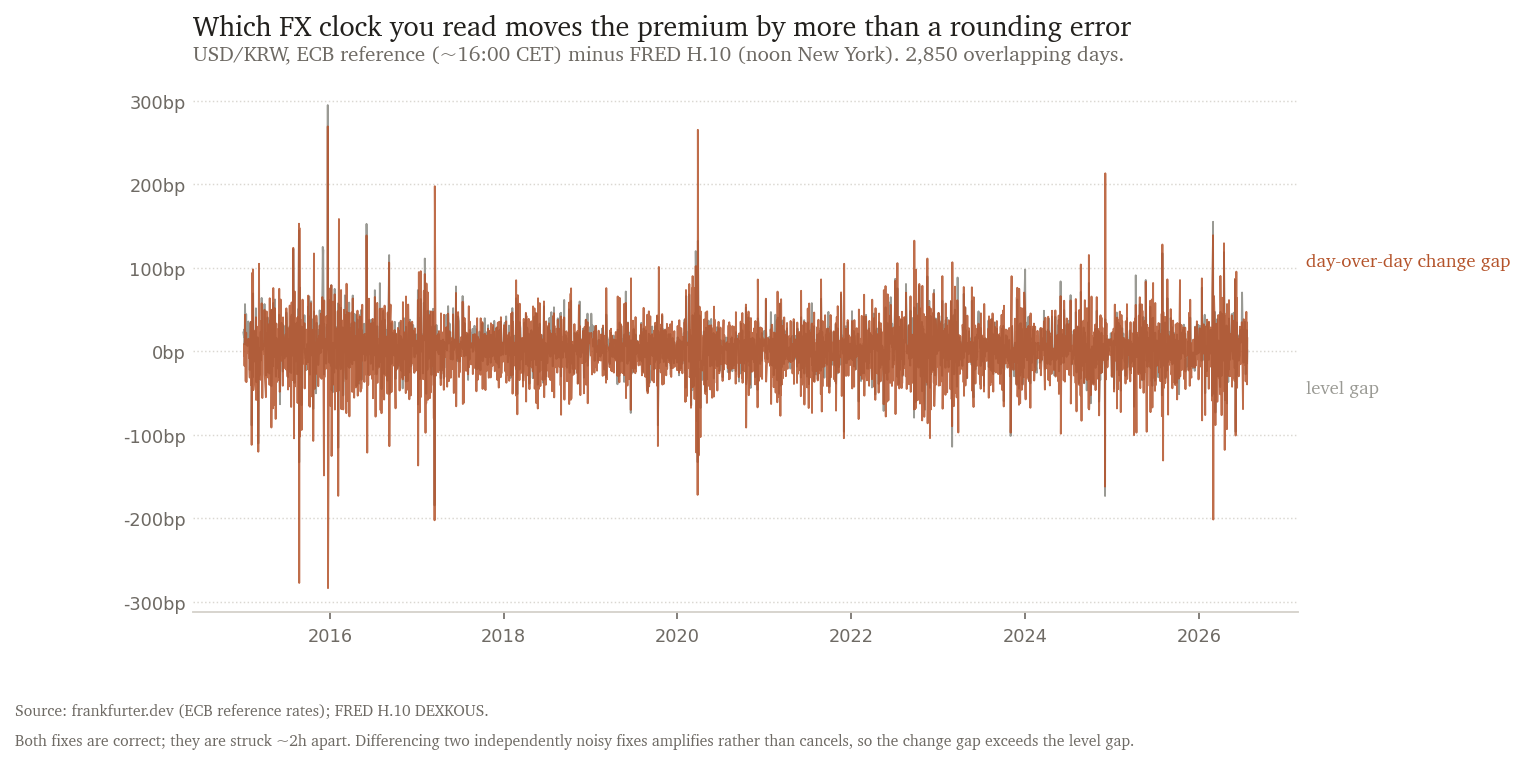

In [6]:
%matplotlib inline
import numpy as np, pandas as pd
from pipeline.viz import theme
from pipeline.measurement.premium import _load_close
from pipeline.measurement.asynchrony import FX_FIX_CALIBRATION
theme.apply()

ecb  = _load_close("d1_prices", "usdkrw_spot_daily")
noon = _load_close("d1_prices", "usdkrw_spot_fred_daily")
shared = ecb.index.intersection(noon.index)

lvl = ((ecb.loc[shared] - noon.loc[shared]) / noon.loc[shared])
chg = (np.log(ecb.loc[shared]).diff() - np.log(noon.loc[shared]).diff()).dropna()

fig, ax = theme.figure(height=4.6)
ax.plot(lvl.index, lvl.values, color=theme.GRAY, linewidth=0.9)
ax.plot(chg.index, chg.values, color=theme.CLAY, linewidth=0.9, alpha=0.85)
theme.bp_axis(ax)
theme.headline(
    ax,
    "Which FX clock you read moves the premium by more than a rounding error",
    "USD/KRW, ECB reference (~16:00 CET) minus FRED H.10 (noon New York). "
    f"{len(shared):,} overlapping days.",
)
# Both series end near 0bp, so anchor the labels at separated fixed heights rather than
# at the (colliding) endpoints.
ax.annotate("day-over-day change gap", xy=(1.0, 0.66), xycoords="axes fraction",
            xytext=(4, 0), textcoords="offset points", color=theme.CLAY,
            fontsize=theme.LABEL_SIZE, va="center", ha="left", fontfamily=theme.SERIF_STACK)
ax.annotate("level gap", xy=(1.0, 0.42), xycoords="axes fraction",
            xytext=(4, 0), textcoords="offset points", color=theme.GRAY,
            fontsize=theme.LABEL_SIZE, va="center", ha="left", fontfamily=theme.SERIF_STACK)
theme.source_note(
    fig, "frankfurter.dev (ECB reference rates); FRED H.10 DEXKOUS.",
    "Both fixes are correct; they are struck ~2h apart. Differencing two independently "
    "noisy fixes amplifies rather than cancels, so the change gap exceeds the level gap.",
)
print(f"LEVEL   mean {lvl.abs().mean()*1e4:6.2f}bp   p95 {lvl.abs().quantile(.95)*1e4:6.2f}bp")
print(f"CHANGE  mean {chg.abs().mean()*1e4:6.2f}bp   p95 {chg.abs().quantile(.95)*1e4:6.2f}bp")
fig;

| Measurement choice | Effect | Basis |
|---|---|---|
| **Close definition** | **24.6bp** | consolidated tape vs. primary-listing official close, 2026-07-28 |
| **FX fix — levels** | 5bp mean / 51bp p95 | ECB vs FRED H.10, 2,850 days |
| **FX fix — changes** | **26.6bp mean / 70.6bp p95** | same pair, 2,849 changes |

**Why the change figure is the one that matters.** The asynchrony decomposition operates
on *changes*, and differencing two independently-noisy fixes **amplifies** rather than
cancels the discrepancy — the change gap is roughly five times the level gap.

For scale: TSM's mean $|\Delta \ln(1+\pi)|$ over 2,327 days is **162bp**. So **~16% of a
typical daily premium move is attributable purely to which FX clock you read.** That is
not a rounding term, and it is the strongest argument for adopting a fix contemporaneous
with the local close.

The close-definition discrepancy has the same character. README recorded 2026-07-28's
close as \$130.49; Nasdaq and one independent provider both report \$130.17. The README
figure is *internally consistent* (130.49/143.02 − 1 = −8.761%, matching its stated
−8.76%), so it is not a typo — it is a **different close print**, almost certainly
consolidated tape against the primary-listing official close. π is a ratio of closes, so
that 24.6bp propagates into every observation.

**Neither default is chosen in code.** Both are config axes with `TODO(ash: ratify)`
defaults, all variants computed side by side, and every artifact records which pair it
used. Burying either in a default would put a noise floor into π that nobody could
decompose afterwards.

### F4 — the comparator: same regime, twenty years older

TSMC's ADR operates under a structurally identical constraint: a quota-bound local→ADR
channel and an uncapped ADR→local one. It is the closest living relative of the SKHY
regime, and it is the training universe — README §8 makes **all** backtesting live on the
comparator panel, with SKHY as forward test only.

{'pair': 'tsmc', 'fx_leg': 'native', 'close_def': 'primary_official', 'fx_series_id': 'usdtwd_spot_daily', 'ratio_confirmed': False, 'n_obs': 2328, 'first': '2016-07-28', 'last': '2026-07-24', 'dropped_to_join': 185, 'mean_pct': 8.876, 'min_pct': -4.966, 'max_pct': 32.865, 'last_pct': 11.204}


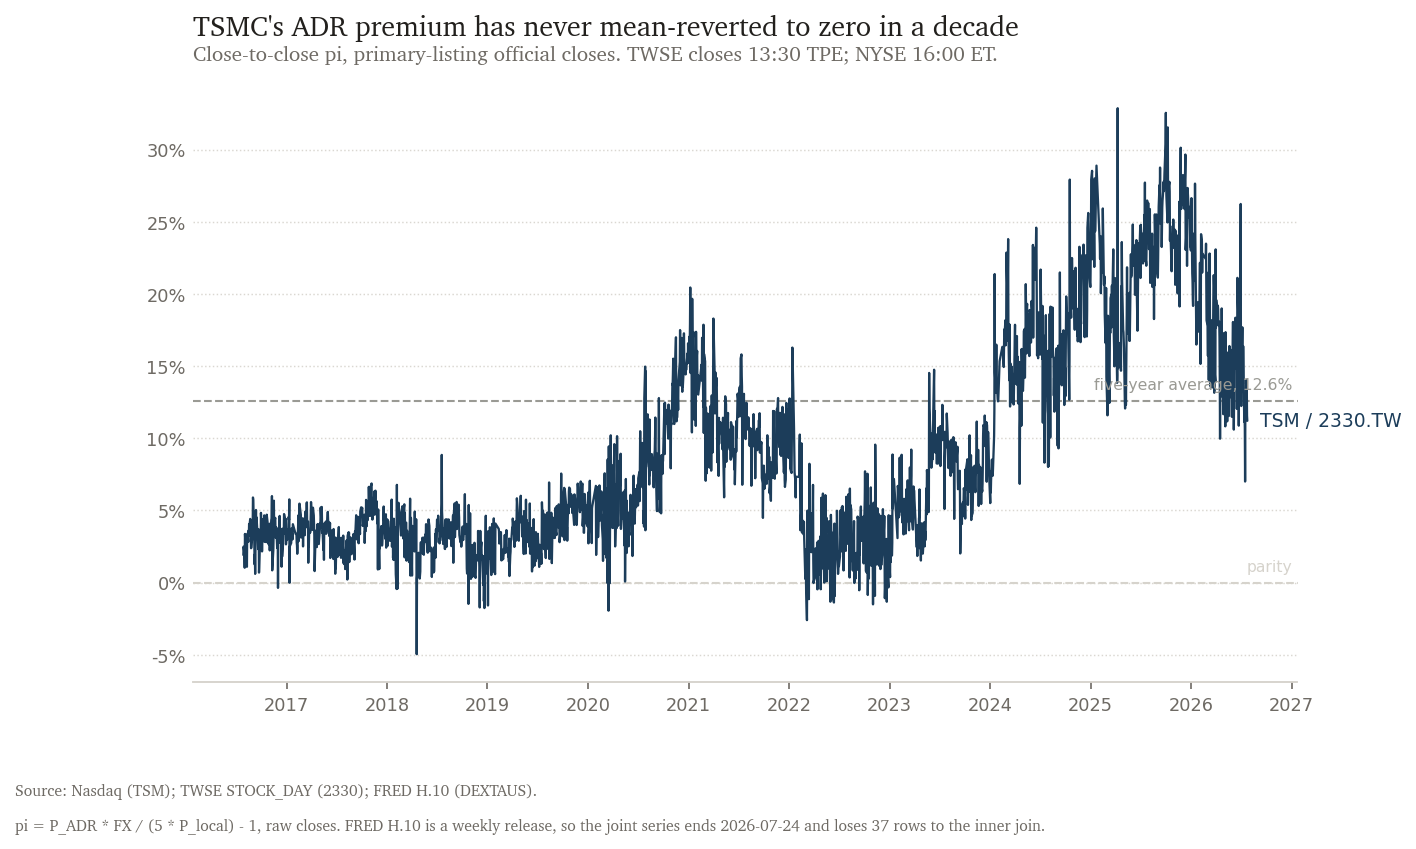

In [7]:
from pipeline.measurement.premium import build_all_variants
v = build_all_variants("tsmc", start="2016-07-28")[0]

fig, ax = theme.figure()
ax.plot(v.series.index, v.series.values, color=theme.INK, linewidth=1.1)
theme.pct_axis(ax)
theme.headline(
    ax,
    "TSMC's ADR premium has never mean-reverted to zero in a decade",
    "Close-to-close pi, primary-listing official closes. TWSE closes 13:30 TPE; NYSE 16:00 ET.",
)
theme.reference_line(ax, 0.126, "five-year average, 12.6%")
theme.reference_line(ax, 0.0, "parity", color=theme.RULE)
theme.label_line_end(ax, v.series.index[-1], v.series.values[-1], "TSM / 2330.TW", theme.INK)
theme.source_note(
    fig, "Nasdaq (TSM); TWSE STOCK_DAY (2330); FRED H.10 (DEXTAUS).",
    "pi = P_ADR * FX / (5 * P_local) - 1, raw closes. FRED H.10 is a weekly release, "
    "so the joint series ends 2026-07-24 and loses 37 rows to the inner join.",
)
print(v.describe())
fig;

**Reading it.** The premium spends the decade positive, ranges roughly 0–33%, and shows
no tendency to decay toward parity. That is the point: under a one-sided barrier,
persistence is the null, not the anomaly. A convergence trade against this series is
short a barrier that does not exist.

The floor is more informative than the ceiling. π rarely goes meaningfully below zero —
that is the *uncapped* ADR→local direction doing its work, reflecting the premium from
below. Above zero there is nothing structural at all.

{'pair': 'skhy', 'fx_leg': 'frankfurter', 'close_def': 'primary_official', 'fx_series_id': 'usdkrw_spot_daily', 'ratio_confirmed': True, 'n_obs': 12, 'first': '2026-07-10', 'last': '2026-07-28', 'dropped_to_join': 2950, 'mean_pct': 27.969, 'min_pct': 15.779, 'max_pct': 51.597, 'last_pct': 22.566}


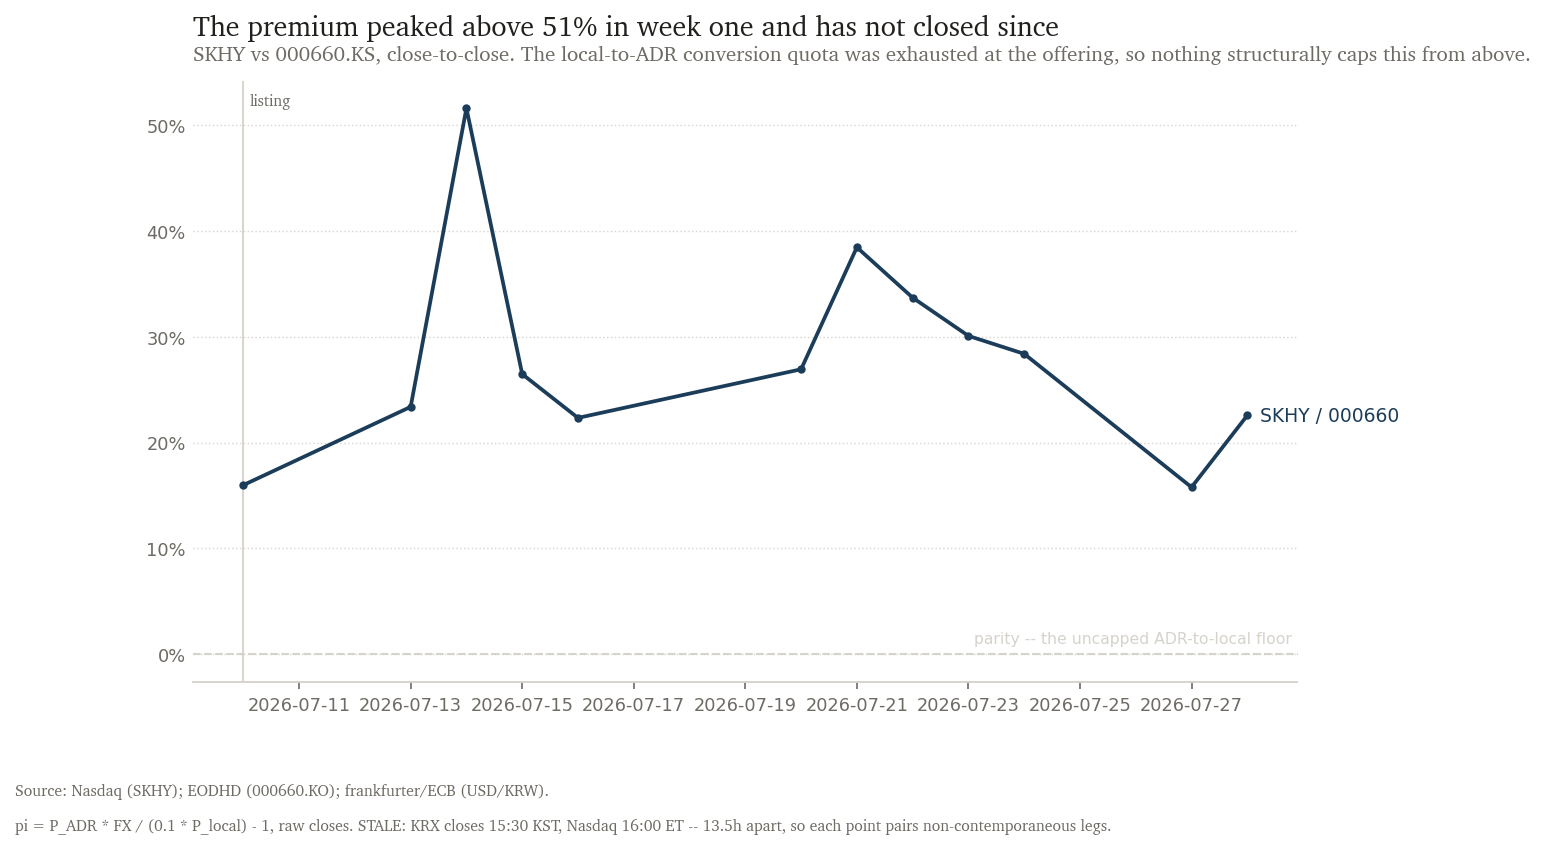

In [8]:
# F1 -- SKHY premium since listing
from pipeline.measurement.premium import build_all_variants
sk = build_all_variants("skhy")[0]

fig, ax = theme.figure()
ax.plot(sk.series.index, sk.series.values, color=theme.INK, linewidth=1.8, marker="o", markersize=3)
theme.pct_axis(ax)
theme.headline(
    ax,
    "The premium peaked above 51% in week one and has not closed since",
    "SKHY vs 000660.KS, close-to-close. The local-to-ADR conversion quota was exhausted "
    "at the offering, so nothing structurally caps this from above.",
)
theme.reference_line(ax, 0.0, "parity -- the uncapped ADR-to-local floor", color=theme.RULE)
theme.label_line_end(ax, sk.series.index[-1], sk.series.values[-1], "SKHY / 000660", theme.INK)
theme.annotate_events(ax, theme.events_for(markets=["US","KR"]),
                      labels={"skhy_adr_listing":"listing","skhy_conversion_open":"conversion opens",
                              "skhy_q2_earnings":"Q2 earnings"})
theme.source_note(
    fig, "Nasdaq (SKHY); EODHD (000660.KO); frankfurter/ECB (USD/KRW).",
    "pi = P_ADR * FX / (0.1 * P_local) - 1, raw closes. STALE: KRX closes 15:30 KST, "
    "Nasdaq 16:00 ET -- 13.5h apart, so each point pairs non-contemporaneous legs.",
)
print(sk.describe())
fig;

**Reading it.** Twelve observations, and already the shape the framework predicts: a
violent early peak, no convergence to parity, and a floor that holds. The premium ranges
15.8%–51.6% and ends at 22.6%.

The floor is the informative part. π never approaches zero from above, because that is
the direction where arbitrage *works* — ADR→local cancellation is uncapped and fast. The
ceiling has no such mechanism, and the path shows it.

**This is 12 observations.** Per README §8, n≈12 is not validation; it is a forward test
in progress. Nothing is fitted to it.

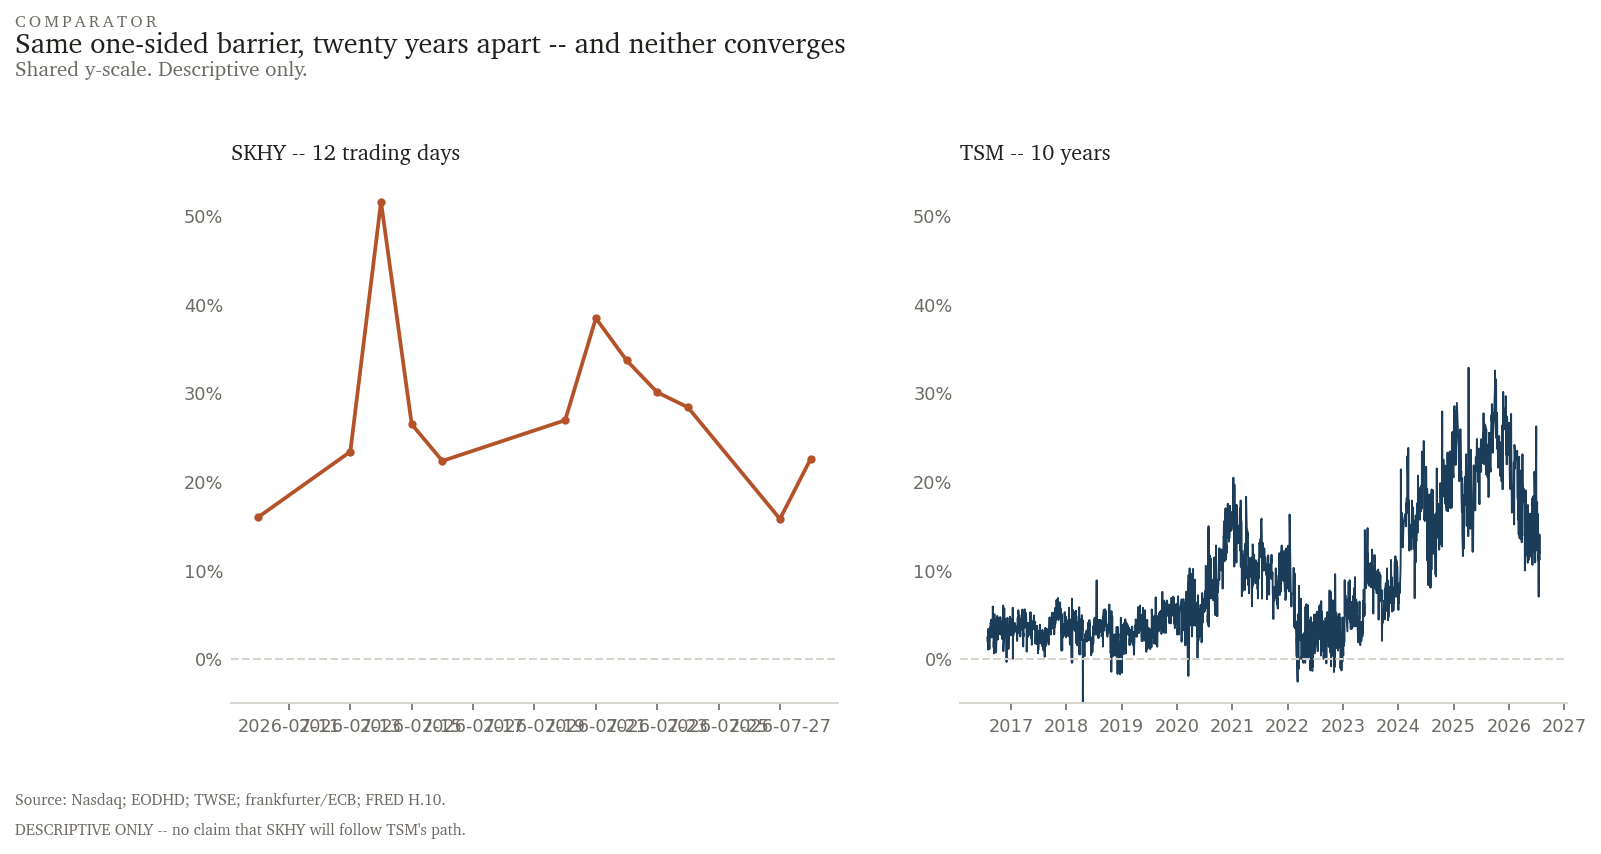

In [9]:
# F5 -- same regime, day one vs year twenty
tsm = build_all_variants("tsmc", start="2016-07-28")[0]

fig, (a1, a2) = theme.figure(ncols=2, figsize=(11.5, 4.6))
for ax in (a1, a2):
    ax.grid(axis="y"); ax.grid(axis="x", visible=False); ax.set_axisbelow(True)

a1.plot(sk.series.index, sk.series.values, color=theme.CLAY, linewidth=1.8, marker="o", markersize=3)
theme.pct_axis(a1); a1.set_ylim(-0.05, 0.55)
a1.set_title("SKHY -- 12 trading days", loc="left", fontsize=10.5,
             color=theme.TEXT, fontfamily=theme.SERIF_STACK)

a2.plot(tsm.series.index, tsm.series.values, color=theme.INK, linewidth=0.9)
theme.pct_axis(a2); a2.set_ylim(-0.05, 0.55)
a2.set_title("TSM -- 10 years", loc="left", fontsize=10.5,
             color=theme.TEXT, fontfamily=theme.SERIF_STACK)
for ax in (a1, a2):
    ax.axhline(0.0, color=theme.RULE, linewidth=1.0, linestyle="--")

theme.finalize(
    fig,
    kicker="comparator",
    headline="Same one-sided barrier, twenty years apart -- and neither converges",
    subtitle="Shared y-scale. Descriptive only.",
    source="Nasdaq; EODHD; TWSE; frankfurter/ECB; FRED H.10.",
    footnote="DESCRIPTIVE ONLY -- no claim that SKHY will follow TSM's path.",
)
fig;

**Descriptive, not predictive.** The shared y-scale invites an inference this notebook
does not make: that SKHY will settle where TSM sits. Nothing here supports that. What the
pair *does* show is that a structurally identical constraint produced a decade of
non-convergence in the mature case — which is the base rate a convergence trade would be
betting against.

TSM's premium is *wider now* than in its early years, so even the direction of drift is
not obviously toward compression.

### F2 and F3 — blocked, and for different reasons

**These figures cannot be drawn yet, and are not simulated, proxied, or backfilled.**

**F2 — measured vs. synthetic contemporaneous π.** Blocked on data that no longer
exists in the form README specified. The synthetic variant D1(b) was to use the
Eurex–KRX night-session KOSPI200 overlap; that link was terminated 2025-06-06. KRX's own
night session (from 2025-06-09) can replace it, but whether day and night bars are
separable in the served data is unverified, and the sanctioned API access is pending.

**F3 — the earnings-morning anatomy.** Blocked on *time*, not on sourcing. The
decomposition needs the 2026-07-29 close on **both** legs. The KRX side has closed; the
**US session has not**. The observation does not exist yet for anyone.

This is worth stating precisely rather than filing under "missing data": the machinery is
built and tested (`pipeline/measurement/asynchrony.py`, identity residual 0.00e+00 on
2,327 real days), the FX-instant component is calibrated on 2,849 changes, and the figure
renders the moment 07-29 closes in New York.

A second, harder limit applies even then. Intraday capture for the 07-28→29 window was
never obtained — Yahoo was rate-limited throughout and free retention is short — so the
decomposition will run at **daily resolution**. It will still attribute the measured jump
across the three legs exactly, but it cannot show the intra-session path: that the local
leg traded the result for a full session while the ADR sat frozen at its prior close.
That specific picture is likely lost permanently, and is recorded as such.

---

## 6. What this sets up

**No results are previewed here.** The measurement layer exists; the modelling does not.

- **M2 — barrier-state regimes**, defined by *arbitrage capacity* — quota headroom,
  borrow availability, short-sale regulatory state — never by narrative labels. Filtered,
  not smoothed, probabilities for anything predictive.
- **M3 — convergence dynamics**, conditional half-life per capacity regime via Jordà local
  projections, estimated on the comparator panel under purged and embargoed walk-forward
  CV.
- **The hypothesis engines**, H1–H5, one at a time, in order of data readiness.

**Registered calls.** See §1's caption cell for the governing status. While the ledger is
unfrozen, every hypothesis is exploratory and is described as such.

**The confound that will not go away.** 2026-07-29 is *simultaneously* the Q2 earnings
release and the conversion open. Two mechanisms — a fundamental shock and a barrier-state
change — are perfectly collinear on the single most informative date in the sample. No
design in this repo claims to separate them; effects spanning that date are reported
jointly, with the confound named.

---

## 7. Reproducibility

This notebook executes **offline**. Ingestion is a separate, logged, network-permitted
stage; analysis modules import no networking library, and that separation is enforced by
a test that walks the AST of every analysis module.

In [10]:
import sys, platform, hashlib, json
import matplotlib, numpy, pandas, yaml as _yaml

print(f"python      {sys.version.split()[0]}   ({platform.platform()})")
for m in (numpy, pandas, matplotlib):
    print(f"{m.__name__:12s}{m.__version__}")
print(f"seed        20260728  (pyproject [tool.charon].random_seed)")
print()
print("Raw data checksums (tests/golden/checksums/):")
for man in sorted((ROOT / "tests" / "golden" / "checksums").glob("*.json")):
    if man.stem == "events_id_ledger": continue
    d = json.loads(man.read_text())
    for rel, sha in sorted(d.get("files", {}).items()):
        print(f"  {sha[:12]}  {rel}")
print()
print("FRED data is Public Domain (citation requested). This work uses the FRED API but")
print("is NOT endorsed or certified by the Federal Reserve Bank of St. Louis.")

python      3.12.13   (macOS-15.6.1-arm64-arm-64bit)
numpy       2.1.3
pandas      2.2.3
matplotlib  3.9.2
seed        20260728  (pyproject [tool.charon].random_seed)

Raw data checksums (tests/golden/checksums/):
  65d53e70f312  data/raw/d1_prices/2026-07-29.3/skhynix_local_daily.csv
  5f623dd5395f  data/raw/d1_prices/2026-07-29/skhy_adr_daily.csv
  494283cd5387  data/raw/d1_prices/2026-07-29/skhynix_local_daily.csv
  13315a3ce180  data/raw/d1_prices/2026-07-29/usdkrw_spot_daily.csv
  68c3692d78fd  data/raw/d1_prices/2026-07-29/usdkrw_spot_fred_daily.csv
  f3dd9ff2e3f0  data/raw/d5_headroom/2026-07-29/skhynix_dr_headroom_capped.csv
  bf8fbfedc457  data/raw/d5_headroom/2026-07-29/skhynix_dr_headroom_legacy.csv
  2786adcb1929  data/raw/d6_comparators/2026-07-29/baba_adr_daily.csv
  8ccbf10b746d  data/raw/d6_comparators/2026-07-29/baba_local_daily.csv
  a0e1ad737c10  data/raw/d6_comparators/2026-07-29/ibn_adr_daily.csv
  c6bb9627f34f  data/raw/d6_comparators/2026-07-29/infy_adr_daily.csv